# Capítulo 6, Sección 6.3 — Ejemplo 2: Ecuación de Burgers con PINNs

Este cuaderno replica computacionalmente el **Ejemplo 2** de la Sección 6.3: resolver un problema directo de dinámica de fluidos 1D usando una **Physics-Informed Neural Network** (**PINN**).

El ejemplo del libro usa la ecuación viscosa de Burgers

$
\frac{\partial u}{\partial t}+u\frac{\partial u}{\partial x}=\nu\frac{\partial^2u}{\partial x^2},
\qquad x\in[-L,L],\quad t\in[0,T].
$

La idea computacional es aproximar todo el campo espacio-temporal con una red neuronal

$
\widehat u(x,t;\theta),
$

y entrenarla castigando tres errores: residuo de la EDP, condición inicial y condición de frontera.

En el test clásico se toma

$
\nu=\frac{0.01}{\pi},\qquad u(x,0)=-\sin(\pi x),
\qquad x\in[-1,1],\qquad t\in[0,1].
$

El libro menciona condiciones de frontera Dirichlet o periódicas; aquí usamos la versión **periódica**, porque es la que se menciona en el análisis estándar del ejemplo. Para validar la red, añadimos un solucionador espectral de referencia. Esa referencia numérica no es parte esencial de la PINN: solo sirve para mirar si la red aprendió algo o si está dibujando arte moderno con aires de ciencia.


## Cómo usarlo

Ejecute las celdas de arriba hacia abajo. En Colab conviene activar GPU:

**Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU**.

El entrenamiento usa derivadas automáticas de primer y segundo orden. Si corre en CPU, reduzca `N_STEPS`, `N_f` o active menos puntos de validación, porque la paciencia humana también es un recurso computacional.


## 1. Importaciones y configuración

Usamos `numpy` para arreglos y visualización, `matplotlib` para gráficas y `torch` para construir la red neuronal y calcular derivadas automáticas.


In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

np.random.seed(23)
torch.manual_seed(23)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch', torch.__version__, '| dispositivo:', device)


PyTorch 2.11.0+cpu | dispositivo: cpu


## 2. Parámetros del problema

Trabajamos en el dominio espacio-temporal

$
(x,t)\in[-1,1]\times[0,1],
$

con viscosidad pequeña

$
\nu=\frac{0.01}{\pi}.
$

La condición inicial es

$
u_0(x)=-\sin(\pi x).
$


In [ ]:
# Dominio
XMIN, XMAX = -1.0, 1.0
L = 1.0
T_FINAL = 1.0

# Viscosidad del test clásico de Burgers con PINNs
NU = 0.01 / np.pi

# Modo de frontera: 'periodic' o 'dirichlet_zero'
BOUNDARY_MODE = 'periodic'

# Hiperparámetros principales
N_f = 7000          # puntos interiores para el residuo de la EDP
N_i = 512           # puntos para la condición inicial
N_b = 512           # puntos para la frontera

N_STEPS = 6500 if device.type == 'cuda' else 2500
PRINT_EVERY = max(250, N_STEPS // 10)

USE_FOURIER_FEATURES = True
USE_LBFGS_AFTER_ADAM = False

print(f'ν = {NU:.8f}')
print(f'N_f={N_f}, N_i={N_i}, N_b={N_b}, pasos Adam={N_STEPS}')


def u0_np(x):
    '''Condición inicial u(x,0).'''
    return -np.sin(np.pi * x)


ν = 0.00318310
N_f=7000, N_i=512, N_b=512, pasos Adam=2500


## 3. Solución numérica de referencia

Burgers con viscosidad pequeña no tiene una solución elemental cómoda para comparar. Por eso resolvemos una referencia numérica con un método espectral periódico y Runge-Kutta 4.

Esta parte **no entrena la PINN**. Solo produce una referencia para comparar al final.


In [ ]:
def solve_burgers_reference(Nx=256, Nt=101, substeps=10, nu=NU):
    '''
    Solucionador espectral periódico para
        u_t + u u_x = nu u_xx
    en x in [-1,1], t in [0,T_FINAL].

    Usa la forma conservativa:
        u_t = - (u^2/2)_x + nu u_xx.
    '''
    x = np.linspace(XMIN, XMAX, Nx, endpoint=False)
    dx = x[1] - x[0]
    t = np.linspace(0.0, T_FINAL, Nt)
    dt = (t[1] - t[0]) / substeps

    # Números de onda para dominio de longitud 2
    k = 2*np.pi*np.fft.fftfreq(Nx, d=dx)
    modes = np.fft.fftfreq(Nx) * Nx
    dealias_mask = np.abs(modes) > (Nx/3)

    def rhs(u):
        u_hat = np.fft.fft(u)
        uxx = np.fft.ifft(-(k**2) * u_hat).real

        q_hat = np.fft.fft(0.5 * u**2)
        q_hat[dealias_mask] = 0.0
        qx = np.fft.ifft(1j * k * q_hat).real
        return -qx + nu * uxx

    U = np.zeros((Nt, Nx), dtype=float)
    u = u0_np(x).astype(float)
    U[0] = u.copy()

    for n in range(Nt - 1):
        for _ in range(substeps):
            k1 = rhs(u)
            k2 = rhs(u + 0.5*dt*k1)
            k3 = rhs(u + 0.5*dt*k2)
            k4 = rhs(u + dt*k3)
            u = u + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)
        U[n+1] = u.copy()
    return x, t, U

x_ref, t_ref, U_ref = solve_burgers_reference()
print('Referencia:', U_ref.shape, '| min/max:', U_ref.min(), U_ref.max())


Referencia: (101, 256) | min/max: -1.0030563340173635 1.0030563340173635


## 4. Visualización de la referencia

Aquí vemos el campo de velocidades calculado por el solucionador clásico. La zona donde los colores cambian bruscamente corresponde al gradiente fuerte tipo choque.


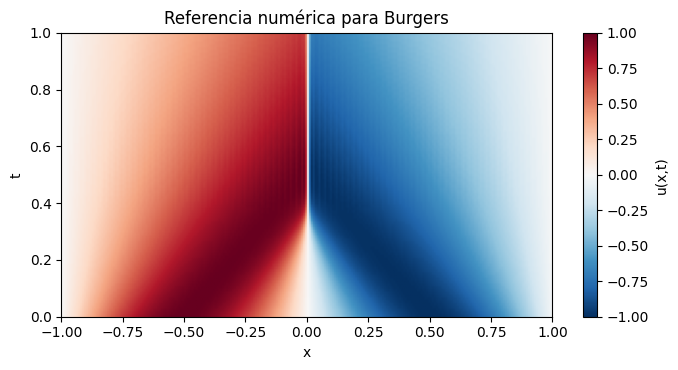

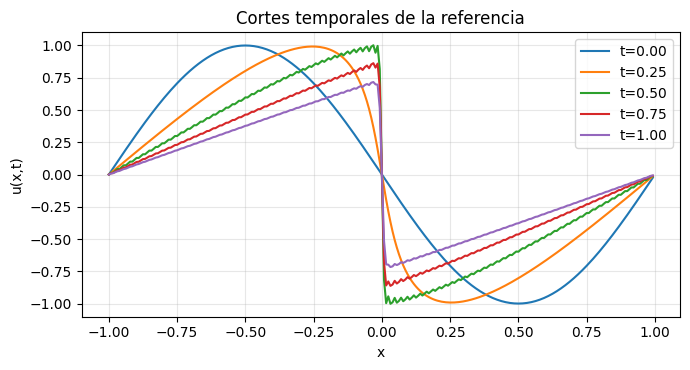

In [ ]:
plt.figure(figsize=(7, 3.8))
plt.imshow(U_ref, origin='lower', aspect='auto', extent=[XMIN, XMAX, 0, T_FINAL],
           cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(label='u(x,t)')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Referencia numérica para Burgers')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 3.8))
for tau in [0.0, 0.25, 0.50, 0.75, 1.0]:
    j = np.argmin(np.abs(t_ref - tau))
    plt.plot(x_ref, U_ref[j], label=f't={t_ref[j]:.2f}')
plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.title('Cortes temporales de la referencia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Muestreo sin malla para la PINN

La PINN no necesita una malla espacio-temporal completa. Tomamos puntos aleatorios para:

1. el residuo físico en el interior $(x_f,t_f)$,
2. la condición inicial $(x_i,0)$,
3. la frontera $(-1,t_b)$ y $(1,t_b)$.

Esto es justamente la gracia sin malla de las PINNs. No hay que construir una discretización temporal CFL, aunque luego el entrenamiento tenga sus propios caprichos, claro.


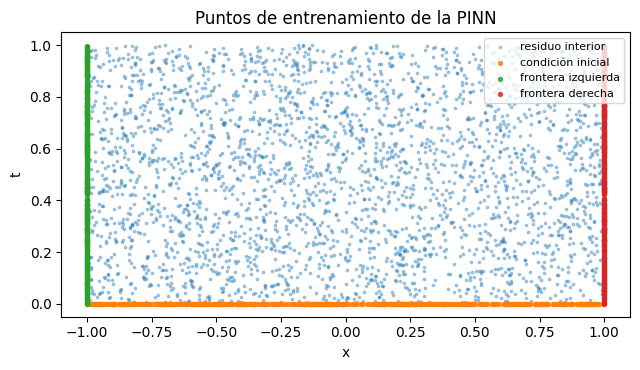

In [ ]:
# Puntos interiores: (x,t) en [-1,1] x [0,1]
x_f_np = XMIN + (XMAX - XMIN) * np.random.rand(N_f)
t_f_np = T_FINAL * np.random.rand(N_f)

# Puntos de condición inicial: t=0
x_i_np = XMIN + (XMAX - XMIN) * np.random.rand(N_i)
t_i_np = np.zeros_like(x_i_np)
u_i_np = u0_np(x_i_np)

# Puntos de frontera: x=-1 y x=1
t_b_np = T_FINAL * np.random.rand(N_b)
x_l_np = XMIN * np.ones_like(t_b_np)
x_r_np = XMAX * np.ones_like(t_b_np)

plt.figure(figsize=(6.5, 3.8))
plt.scatter(x_f_np[:3000], t_f_np[:3000], s=3, alpha=0.35, label='residuo interior')
plt.scatter(x_i_np, t_i_np, s=8, alpha=0.8, label='condición inicial')
plt.scatter(x_l_np, t_b_np, s=8, alpha=0.8, label='frontera izquierda')
plt.scatter(x_r_np, t_b_np, s=8, alpha=0.8, label='frontera derecha')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Puntos de entrenamiento de la PINN')
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()


## 6. Tensores de PyTorch

Convertimos los arreglos de `numpy` en tensores. Los puntos donde necesitamos derivadas respecto a \(x\) o \(t\) se crean con `requires_grad=True`.


In [ ]:
def to_col(a, requires_grad=False):
    t = torch.tensor(a, dtype=torch.float32, device=device).reshape(-1, 1)
    return t.requires_grad_(requires_grad)

# Interior: necesitamos u_t, u_x y u_xx
x_f = to_col(x_f_np, requires_grad=True)
t_f = to_col(t_f_np, requires_grad=True)

# Inicial: solo valor de la red
x_i = to_col(x_i_np)
t_i = to_col(t_i_np)
u_i = to_col(u_i_np)

# Frontera: para periodicidad usamos también u_x en ambos extremos
x_l = to_col(x_l_np, requires_grad=True)
x_r = to_col(x_r_np, requires_grad=True)
t_b = to_col(t_b_np)


## 7. Arquitectura de la red neuronal

La red recibe coordenadas $(x,t)$ y devuelve un número:

$
(x,t)\longmapsto \widehat u(x,t;\theta).
$

Uso una MLP con `tanh`. Además dejo activadas características tipo Fourier para ayudar con la periodicidad espacial y la formación de gradientes fuertes. La formulación PINN no cambia: solo estamos dándole entradas menos miserables a la red, que bastante drama tiene ya con Burgers.


In [ ]:
class MLP(nn.Module):
    def __init__(self, width=80, depth=5, use_fourier=True,
                 x_freqs=(1, 2, 3, 4), t_freqs=(1, 2, 3)):
        super().__init__()
        self.use_fourier = use_fourier
        self.register_buffer('x_freqs', torch.tensor(x_freqs, dtype=torch.float32).reshape(1, -1))
        self.register_buffer('t_freqs', torch.tensor(t_freqs, dtype=torch.float32).reshape(1, -1))

        if use_fourier:
            in_dim = 2 + 2*len(x_freqs) + 2*len(t_freqs)
        else:
            in_dim = 2

        dims = [in_dim] + [width]*depth + [1]
        layers = []
        for j in range(len(dims) - 1):
            layers.append(nn.Linear(dims[j], dims[j+1]))
            if j < len(dims) - 2:
                layers.append(nn.Tanh())
        self.net = nn.Sequential(*layers)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def encode(self, x, t):
        if not self.use_fourier:
            return torch.cat([x, t], dim=1)

        # x tiene periodo 2 en [-1,1], por eso usamos pi*f*x.
        sx = torch.sin(np.pi * x * self.x_freqs)
        cx = torch.cos(np.pi * x * self.x_freqs)

        # t no es una variable periódica física, pero estas funciones ayudan a representar variación temporal.
        st = torch.sin(2*np.pi * t * self.t_freqs / T_FINAL)
        ct = torch.cos(2*np.pi * t * self.t_freqs / T_FINAL)
        return torch.cat([x, t, sx, cx, st, ct], dim=1)

    def forward(self, x, t):
        return self.net(self.encode(x, t))

net = MLP(use_fourier=USE_FOURIER_FEATURES).to(device)
print(net)
print('Parámetros entrenables:', sum(p.numel() for p in net.parameters()))


MLP(
  (net): Sequential(
    (0): Linear(in_features=16, out_features=80, bias=True)
    (1): Tanh()
    (2): Linear(in_features=80, out_features=80, bias=True)
    (3): Tanh()
    (4): Linear(in_features=80, out_features=80, bias=True)
    (5): Tanh()
    (6): Linear(in_features=80, out_features=80, bias=True)
    (7): Tanh()
    (8): Linear(in_features=80, out_features=80, bias=True)
    (9): Tanh()
    (10): Linear(in_features=80, out_features=1, bias=True)
  )
)
Parámetros entrenables: 27361


## 8. Residuo de Burgers por diferenciación automática

El residuo de la ecuación es

$
r(x,t)=\widehat u_t+\widehat u\,\widehat u_x-\nu\widehat u_{xx}.
$

La PINN intenta hacer que este residuo sea cercano a cero en puntos interiores del dominio.


In [ ]:
def grad(outputs, inputs):
    return torch.autograd.grad(
        outputs, inputs,
        grad_outputs=torch.ones_like(outputs),
        create_graph=True,
        retain_graph=True
    )[0]


def burgers_residual(model, x, t):
    u = model(x, t)
    u_t = grad(u, t)
    u_x = grad(u, x)
    u_xx = grad(u_x, x)
    return u_t + u*u_x - NU*u_xx


## 9. Función de pérdida

La pérdida total tiene la forma del libro:

$
L(\theta)=\lambda_fL_f+\lambda_iL_i+\lambda_bL_b.
$

Donde:

$
L_f=\frac1{N_f}\sum |\widehat u_t+\widehat u\widehat u_x-\nu\widehat u_{xx}|^2,
$

$
L_i=\frac1{N_i}\sum |\widehat u(x_i,0)-u_0(x_i)|^2.
$

Para frontera periódica usamos

$
\widehat u(-1,t)=\widehat u(1,t),
\qquad
\widehat u_x(-1,t)=\widehat u_x(1,t).
$


In [ ]:
lambda_f = 1.0
lambda_i = 50.0
lambda_b = 10.0


def boundary_loss(model):
    u_l = model(x_l, t_b)
    u_r = model(x_r, t_b)

    if BOUNDARY_MODE == 'periodic':
        ux_l = grad(u_l, x_l)
        ux_r = grad(u_r, x_r)
        return ((u_l - u_r)**2).mean() + ((ux_l - ux_r)**2).mean()

    if BOUNDARY_MODE == 'dirichlet_zero':
        return (u_l**2).mean() + (u_r**2).mean()

    raise ValueError("BOUNDARY_MODE debe ser 'periodic' o 'dirichlet_zero'.")


def loss_terms(model):
    r = burgers_residual(model, x_f, t_f)
    loss_f = (r**2).mean()
    loss_i = ((model(x_i, t_i) - u_i)**2).mean()
    loss_b = boundary_loss(model)
    total = lambda_f*loss_f + lambda_i*loss_i + lambda_b*loss_b
    return total, loss_f, loss_i, loss_b


## 10. Entrenamiento con Adam

En cada iteración:

1. se evalúa la pérdida,
2. PyTorch calcula gradientes con `backward`,
3. Adam actualiza los pesos de la red.


In [ ]:
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=max(1000, N_STEPS//3), gamma=0.5)

hist = {'total': [], 'pde': [], 'ic': [], 'bc': []}
start = time.time()

for it in range(N_STEPS + 1):
    optimizer.zero_grad(set_to_none=True)
    loss, lf, li, lb = loss_terms(net)
    loss.backward()
    optimizer.step()
    scheduler.step()

    hist['total'].append(float(loss.detach().cpu()))
    hist['pde'].append(float((lambda_f*lf).detach().cpu()))
    hist['ic'].append(float((lambda_i*li).detach().cpu()))
    hist['bc'].append(float((lambda_b*lb).detach().cpu()))

    if it % PRINT_EVERY == 0:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'it={it:5d} | total={hist["total"][-1]:.3e} | '
              f'λfLf={hist["pde"][-1]:.3e} | λiLi={hist["ic"][-1]:.3e} | '
              f'λbLb={hist["bc"][-1]:.3e} | lr={lr_now:.1e}')

print(f'Tiempo de entrenamiento: {time.time() - start:.1f} s')


it=    0 | total=5.752e+01 | λfLf=1.273e+01 | λiLi=4.395e+01 | λbLb=8.393e-01 | lr=1.0e-03
it=  250 | total=2.891e-01 | λfLf=2.706e-01 | λiLi=1.536e-02 | λbLb=3.146e-03 | lr=1.0e-03
it=  500 | total=2.257e-01 | λfLf=2.168e-01 | λiLi=8.440e-03 | λbLb=5.075e-04 | lr=1.0e-03
it=  750 | total=2.078e-01 | λfLf=2.002e-01 | λiLi=7.422e-03 | λbLb=2.104e-04 | lr=1.0e-03
it= 1000 | total=1.950e-01 | λfLf=1.880e-01 | λiLi=6.953e-03 | λbLb=9.993e-05 | lr=5.0e-04
it= 1250 | total=1.879e-01 | λfLf=1.811e-01 | λiLi=6.678e-03 | λbLb=6.885e-05 | lr=5.0e-04
it= 1500 | total=1.783e-01 | λfLf=1.718e-01 | λiLi=6.354e-03 | λbLb=5.564e-05 | lr=5.0e-04
it= 1750 | total=1.600e-01 | λfLf=1.540e-01 | λiLi=5.896e-03 | λbLb=6.355e-05 | lr=5.0e-04
it= 2000 | total=1.065e-01 | λfLf=1.020e-01 | λiLi=4.366e-03 | λbLb=1.124e-04 | lr=2.5e-04
it= 2250 | total=6.363e-02 | λfLf=6.091e-02 | λiLi=2.525e-03 | λbLb=1.952e-04 | lr=2.5e-04
it= 2500 | total=3.430e-02 | λfLf=3.273e-02 | λiLi=1.276e-03 | λbLb=2.942e-04 | lr=2.5e-04

## 11. Refinamiento opcional con L-BFGS

En PINNs es común usar Adam primero y luego L-BFGS para refinar. Lo dejo apagado por defecto porque puede tardar. Si quiere más precisión, cambie arriba:

```python
USE_LBFGS_AFTER_ADAM = True
```


In [ ]:
if USE_LBFGS_AFTER_ADAM:
    lbfgs = torch.optim.LBFGS(
        net.parameters(),
        max_iter=500,
        tolerance_grad=1e-9,
        tolerance_change=1e-11,
        history_size=50,
        line_search_fn='strong_wolfe'
    )

    def closure():
        lbfgs.zero_grad(set_to_none=True)
        loss, _, _, _ = loss_terms(net)
        loss.backward()
        return loss

    print('Ejecutando L-BFGS...')
    lbfgs.step(closure)
    loss, lf, li, lb = loss_terms(net)
    print(f'Después de L-BFGS | total={float(loss.detach().cpu()):.3e} | \
          Lf={float(lf.detach().cpu()):.3e} | Li={float(li.detach().cpu()):.3e} | Lb={float(lb.detach().cpu()):.3e}')
else:
    print('L-BFGS desactivado.')

L-BFGS desactivado.


## 12. Evaluación de la PINN

Ahora evaluamos la red sobre la misma malla usada por la referencia numérica. Aquí ya no calculamos gradientes; solo predicciones.


In [ ]:
TT_eval, XX_eval = np.meshgrid(t_ref, x_ref, indexing='ij')

with torch.no_grad():
    U_pred = net(to_col(XX_eval.ravel()), to_col(TT_eval.ravel()))
    U_pred = U_pred.cpu().numpy().reshape(U_ref.shape)

abs_err = np.abs(U_pred - U_ref)
rel_l2 = np.sqrt(np.mean((U_pred - U_ref)**2)) / np.sqrt(np.mean(U_ref**2))
max_err = abs_err.max()

print(f'Error relativo L2 frente a referencia: {rel_l2:.4e}')
print(f'Error absoluto máximo: {max_err:.4e}')


Error relativo L2 frente a referencia: 9.9460e-02
Error absoluto máximo: 5.4588e-01


## 13. Resultados visuales

Primero miramos el historial de pérdida; luego comparamos referencia, PINN y error absoluto.


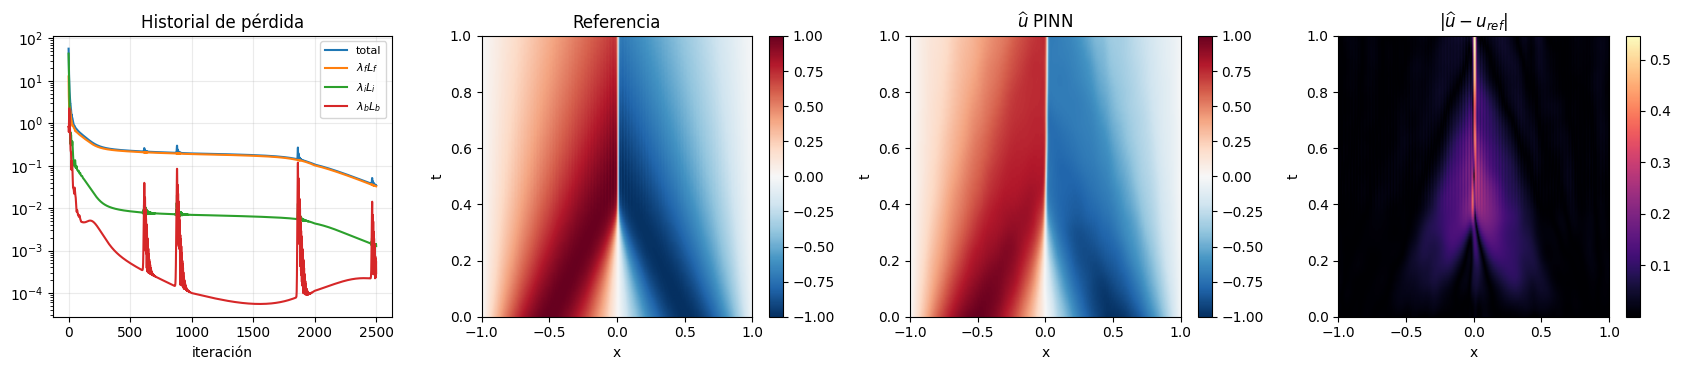

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(17, 3.8))

axs[0].semilogy(hist['total'], label='total')
axs[0].semilogy(hist['pde'], label=r'$\lambda_f L_f$')
axs[0].semilogy(hist['ic'], label=r'$\lambda_i L_i$')
axs[0].semilogy(hist['bc'], label=r'$\lambda_b L_b$')
axs[0].set_title('Historial de pérdida')
axs[0].set_xlabel('iteración')
axs[0].grid(True, alpha=0.25)
axs[0].legend(fontsize=8)

im1 = axs[1].imshow(U_ref, origin='lower', aspect='auto', extent=[XMIN, XMAX, 0, T_FINAL],
                    cmap='RdBu_r', vmin=-1, vmax=1)
axs[1].set_title('Referencia')
axs[1].set_xlabel('x')
axs[1].set_ylabel('t')
fig.colorbar(im1, ax=axs[1])

im2 = axs[2].imshow(U_pred, origin='lower', aspect='auto', extent=[XMIN, XMAX, 0, T_FINAL],
                    cmap='RdBu_r', vmin=-1, vmax=1)
axs[2].set_title(r'$\widehat u$ PINN')
axs[2].set_xlabel('x')
axs[2].set_ylabel('t')
fig.colorbar(im2, ax=axs[2])

im3 = axs[3].imshow(abs_err, origin='lower', aspect='auto', extent=[XMIN, XMAX, 0, T_FINAL],
                    cmap='magma')
axs[3].set_title(r'$|\widehat u-u_{ref}|$')
axs[3].set_xlabel('x')
axs[3].set_ylabel('t')
fig.colorbar(im3, ax=axs[3])

plt.tight_layout()
plt.show()


## 14. Comparación por cortes temporales

Estos cortes son más honestos que solo mirar el mapa de calor. Si la PINN suaviza demasiado el choque, aquí se nota sin piedad.


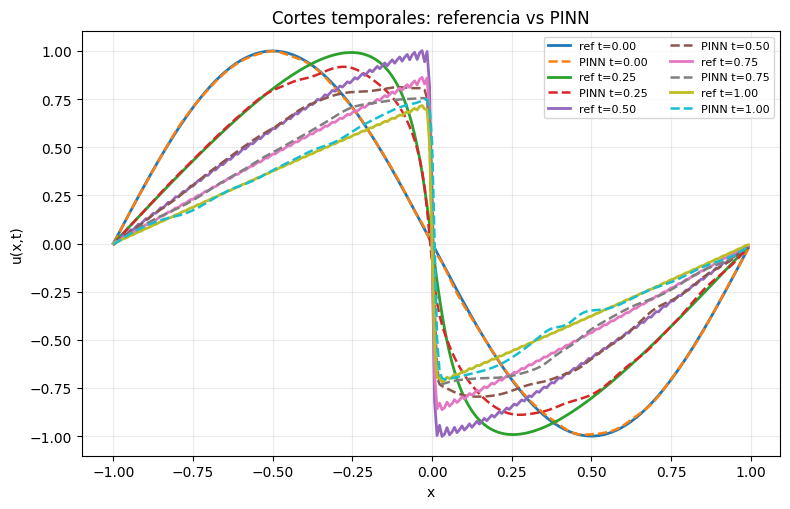

In [ ]:
plt.figure(figsize=(8, 5.2))
for tau in [0.0, 0.25, 0.50, 0.75, 1.0]:
    j = np.argmin(np.abs(t_ref - tau))
    plt.plot(x_ref, U_ref[j], '-', lw=2, label=f'ref t={t_ref[j]:.2f}')
    plt.plot(x_ref, U_pred[j], '--', lw=1.8, label=f'PINN t={t_ref[j]:.2f}')
plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.title('Cortes temporales: referencia vs PINN')
plt.grid(True, alpha=0.25)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


## 15. Chequeo independiente del residuo

Finalmente evaluamos el residuo de la EDP en puntos aleatorios nuevos que la red no vio durante el entrenamiento.


In [ ]:
N_check = 3000
x_c_np = XMIN + (XMAX - XMIN) * np.random.rand(N_check)
t_c_np = T_FINAL * np.random.rand(N_check)
x_c = to_col(x_c_np, requires_grad=True)
t_c = to_col(t_c_np, requires_grad=True)

r_c = burgers_residual(net, x_c, t_c).detach().cpu().numpy().ravel()
print('Residuo en puntos nuevos')
print('RMSE:', np.sqrt(np.mean(r_c**2)))
print('MAE :', np.mean(np.abs(r_c)))
print('MAX :', np.max(np.abs(r_c)))


Residuo en puntos nuevos
RMSE: 0.2213932
MAE : 0.13806346
MAX : 2.6164894


## Lectura esperada de resultados

Si todo va razonablemente bien, debería ver:

- La pérdida total bajando en escala logarítmica.
- La condición inicial aprendida con bastante fidelidad.
- Un campo $\widehat u(x,t)$ que reproduce la propagación y formación del gradiente fuerte.
- Error más grande cerca de la región de choque.

Esto último no es un accidente: las PINNs estándar suelen suavizar frentes abruptos porque una red neuronal global y suave tiende a repartir el error. Justamente por eso el libro menciona estrategias como muestreo adaptativo o más puntos cerca de la región de choque para mejorar la resolución.
